## CSCI-4041 - Algorithms - Chapter 13

## Balanced Binary Search Tree Examples

### Joy Upton Azzam

### 2/18/2026

<mark>_____________________________________________________________________________________</mark>

## Load the Binary Search Tree

In [1]:
%%capture
%run Ch12_BinarySearchTree.ipynb

<mark>_____________________________________________________________________________________</mark>

## A Binary Search Tree with Rotations

The following class ```balancedtree``` is a child of ```binarysearchtree``` and contains two additional functions based on page 336 of chapter 13 in the CLRS textbook. The rotation operations are fundamental to the balanced tree schemes that have been developed. The rotation below preserves the binary search tree property while changing the balance locally in the tree.

In [2]:
class balancedtree(binarysearchtree):
    """a child class with rotation tools"""

    ##################################################################### nested sub-class for nodes
    class node:
        """(nested) node class for linkedlist"""
        
        def __init__(self,k=None,parent=None,left_child=None,right_child=None):
            """constructor for node objects"""
            self.p = parent
            self.left = left_child
            self.right = right_child
            self.key = k
            self.height = 0
    #####################################################################
    
    def compute_height(self,x):
        """computes the height of node x based on the (current) left and right child"""
        if x.left:
            left_height = 1 + x.left.height   # left height (if left child exists)
        else:
            left_height = 0
        if x.right:
            right_height = 1 + x.right.height # right height (io the right child exists)
        else:
            right_height = 0
        
        return left_height,right_height   # return the balance numbers for the tree

    def update_height(self,x):
        """updates the height of node x"""
        # call the function to compute the two heights
        left_height,right_height = self.compute_height(x)
        
        # update the height of x based on the maximum height of x's children (if any)
        x.height = max(left_height,right_height)
        
        return left_height,right_height   # return the balance numbers for the tree
    
    def left_rotate(self,x):
        """rotate node x to the left"""
        y = x.right
        x.right = y.left    # move middle sub-tree       (x.right must exist)
        if y.left != None:
            y.left.p = x
        y.p = x.p           # link y to x's parent
        if x.p == None:
            self.root = y
        elif x==x.p.left:   # link x's parent to y
            x.p.left = y
        else:
            x.p.right = y
        y.left = x          # re-link y and x
        x.p = y

        self.update_height(x)
        if x.p:
            self.update_height(x.p)

    def right_rotate(self,x):
        """rotate node x to the right"""
        y = x.left
        x.left = y.right    # move middle sub-tree     (x.left must exist)
        if y.right != None:
            y.right.p = x
        y.p = x.p           # link y to x's parent
        if x.p == None:
            self.root = y
        elif x==x.p.right:   # link x's parent to y
            x.p.right = y
        else:
            x.p.left = y
        y.right = x          # re-link y and x
        x.p = y
        
        self.update_height(x)
        if x.p:
            self.update_height(x.p)

    def insert(self,k):
        """an updated insert method"""
        super().insert(k)               # old insert

        # update the heights going back up
        x = self.search(self.root,k)    # node inserted
        if x.key==k:
            while x.p:
                x = x.p
                self.update_height(x)          # compute the height

    def delete(self,k):
        """an updated delete method - which deletes key k from the tree"""
        x = self.root
        z = None
        while x != None:
            z = x
            if z.key == k:    # we are deleting node z below
                break
            elif k < x.key:
                x = x.left
            else:
                x = x.right
        if z.key == k:        # check if we found key k for node z
            ################### delete node z #######################################
            print("key =",k,"was found")
            if z.left == None:                   # z only has a right child (maybe)
                self.transplant(z,z.right)
            elif z.right == None:                # z only has a left child (maybe)
                self.transplant(z,z.left)
            else: # z has two children
                y = self.min(z.right)            # in-order successor of z
                if y != z.right:                 # 
                    self.transplant(y,y.right)   # y can only have a right child
                    y.right = z.right            # link y to z's right child
                    y.right.p = y                # z's right childs parent link to y
                self.transplant(z,y) # move y to z's position
                y.left = z.left      # connect the left sub-tree from z to y
                y.left.p = y         # z's left childs parent link to y
                self.update_height(y)          # compute the height (for transplant)
            ########################################################################## Done deleting z

            # update the heights going back up the deletion search path
            while z.p:
                z = z.p
                self.update_height(z)          # compute the height

### 2. Printing Utility Functions for Link-based Trees

This version is slightly different than that from the previous file. The data structures used for the coordinate information was switched for the array-based tree, so I updated this code to use a similar design. In this case, we don't have indices (integers) for each node, so I have used a python dictionary which is keyed by the reference to the node itself. The coords structure still holds the same information for plotting: x-coordinate, y-coordinate, node key, reference to the parent node. The last item is used to draw the edges of the tree.

In [3]:
def get_coordinates(T):
    """traverses a binary linked tree in-order computing the coordinates and saving information as needed"""
    
    def in_order(node,depth):
        """(recursive) in-order traversal of tree starting from node p"""
        nonlocal x,coords
        
        if node:
            in_order(node.left,depth+1)
            
            #------------------------in-order actions--------------------------------------
            # coordinate data[node reference]  =  (  in-order # , depth , key , height, balance, parent reference )
            if 'height' in dir(node):
                coords[node] = (x,-depth,node.key,node.height,T.compute_height(node),node.p)
            else:
                coords[node] = (x,-depth,node.key,node.p)
            x += 1                                    # update count
            #------------------------------------------------------------------------------
            
            in_order(node.right,depth+1)
    
    x = 0              # initialize the count of nodes (x-coordinate)
    coords = {}        # data dictionary
    
    in_order(T.root,0) # start the traversal to compute coordinates
    
    return coords      # return (in-order) coordinate set with parent references

In [4]:
import matplotlib.pyplot as plt


def PrintTree(T,scale=0.5,node_size=500,font=12):
    """Creates a scatter plot of a binary linked tree"""
    
    fig, ax = plt.subplots()            # create image (figure/axis) object
    
    coords = get_coordinates(T)         # call recursive coordinate code

    b = 0.75 # outer border for image
    ax.set_xlim([-b, len(coords)])    # set the image frame (axis) limits
    ax.set_ylim([min([data[1] for hash_key,data in coords.items()])-b, b])
    
    for hash_key,data in coords.items():      # loop over the (hash)keys and values of coordinate data dictionary
        if len(data)==6:
            x,y,key,height,balance,parent = data         # extract data parts (node
            text = str(key)+"\n"+str(height)+"\n"+str(balance)
        else:
            x,y,key,parent = data         # extract data parts (node
            text = str(key)
        # Plot the point for the node
        ax.scatter([x],[y],s=node_size,zorder=2,color="olive")
        
        # Add the annotation for the text of the nodes key
        ax.annotate(text, xy=(x,y), xytext=(x,y), 
                    fontsize=font, ha='center',va='center',zorder=3)
        
        # Add the lines for parent child-relationship
        if parent:
            px,py = coords[parent][0],coords[parent][1] # extract parent data from dictionary
            ax.annotate("",
                    xy=(px,py), xytext=(x,y),
                    arrowprops=dict(arrowstyle="-",connectionstyle="arc3",color="darkgoldenrod")
                   ,zorder=1)
    
    plt.gcf().set_size_inches(16*scale, 9*scale)    # set figure size
    plt.show()                                      # display the figure

### Example Usage

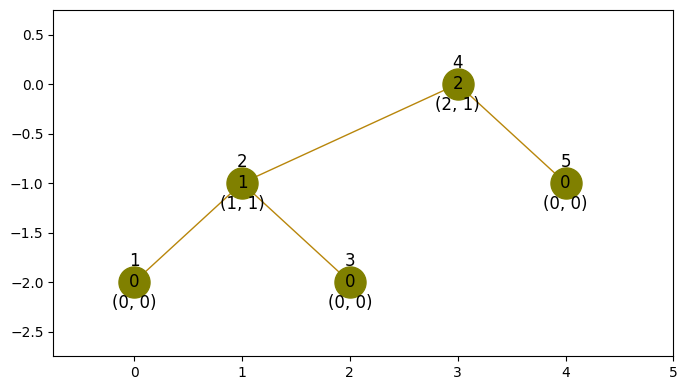

In [5]:
BST = balancedtree()

BST.insert(4)             # call insert
BST.insert(2)             # call insert
BST.insert(5)             # call insert
BST.insert(1)             # call insert
BST.insert(3)             # call insert

PrintTree(BST)

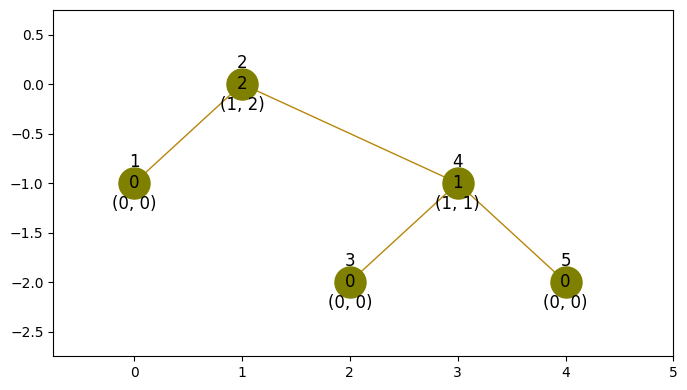

In [6]:
# rotate the root to the right
BST.right_rotate(BST.root)
PrintTree(BST)

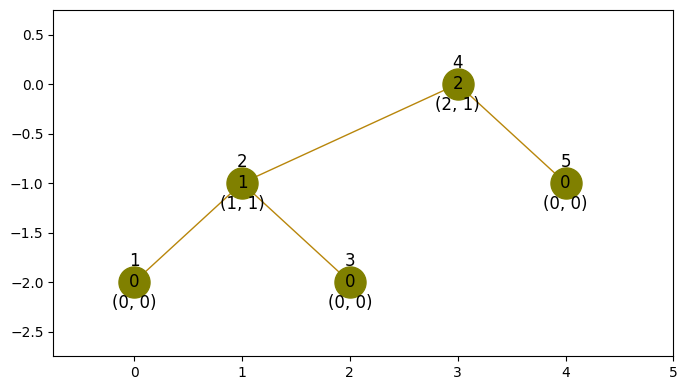

In [7]:
# rotate the root to the left
BST.left_rotate(BST.root)

PrintTree(BST)

key = 1 was found


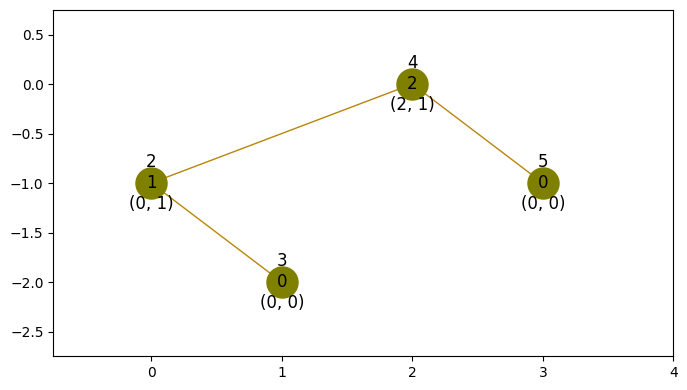

In [8]:
# deleting a leaf
BST.delete(1)
PrintTree(BST)

key = 2 was found


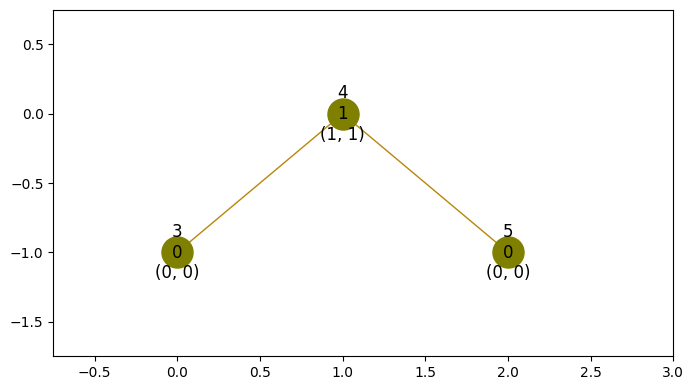

In [9]:
# case 2: deleting a node with a single child (forces re-compute of heights)
BST.delete(2)
PrintTree(BST)

key = 4 was found


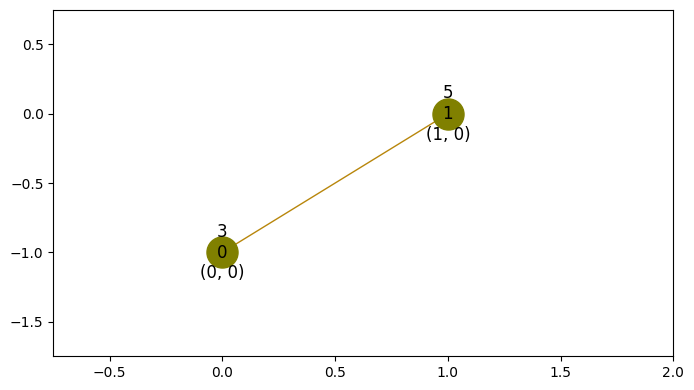

In [10]:
# case III: deleting a node with 2 children (and the root -re-compute transplant)
BST.delete(4)
PrintTree(BST)